<a href="https://www.kaggle.com/code/mdramjanali/electrochemical-modeling-of-silicon-lithium?scriptVersionId=336965699" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mdramjanali/electrochemical-modeling-of-silicon-in-lithium-ion/readme.txt
/kaggle/input/datasets/mdramjanali/electrochemical-modeling-of-silicon-in-lithium-ion/Electrodes_and_Electrochemical_test_information/Test_tracking_Si_Halfcells.xlsx
/kaggle/input/datasets/mdramjanali/electrochemical-modeling-of-silicon-in-lithium-ion/Electrodes_and_Electrochemical_test_information/readme.txt
/kaggle/input/datasets/mdramjanali/electrochemical-modeling-of-silicon-in-lithium-ion/Electrodes_and_Electrochemical_test_information/Cell_Slurry_Mastersheet.xlsx
/kaggle/input/datasets/mdramjanali/electrochemical-modeling-of-silicon-in-lithium-ion/Figure 5/Figure5B_V_Q_nonPulse_mAh_g.m
/kaggle/input/datasets/mdramjanali/electrochemical-modeling-of-silicon-in-lithium-ion/Figure 5/Figure5B_C40_mAh_g_10_40_100nm.xlsx
/kaggle/input/datasets/mdramjanali/electrochemical-modeling-of-silicon-in-lithium-ion/Figure 5/Figure5.pptx
/kaggle/input/datasets/mdramjanali/electrochemical-modeling-of-si

In [2]:
path = '/kaggle/input/datasets/mdramjanali/electrochemical-modeling-of-silicon-in-lithium-ion'
print("Files in dataset:")
print(os.listdir(path))

Files in dataset:
['Electrodes_and_Electrochemical_test_information', 'Figure 5', 'Figure 2', 'Figure 4', 'Figure 1', 'Figure 3', 'readme.txt', 'Figure S2', 'Figure 7', 'Figure 8', 'Figure 6', 'Figure S1']


In [3]:
base_path = '/kaggle/input/datasets/mdramjanali/electrochemical-modeling-of-silicon-in-lithium-ion'

# Read Cell Slurry Mastersheet (cell mass, active material loadings, slurry details)
df_master = pd.read_excel(f'{base_path}/Electrodes_and_Electrochemical_test_information/Cell_Slurry_Mastersheet.xlsx')
print("--- Cell Slurry Mastersheet ---")
display(df_master.head())

# Read Test Tracking sheet
df_tracking = pd.read_excel(f'{base_path}/Electrodes_and_Electrochemical_test_information/Test_tracking_Si_Halfcells.xlsx')
print("--- Test Tracking ---")
display(df_tracking.head())

--- Cell Slurry Mastersheet ---


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,Name,Materials,Supplier,Link,Desciption,Comments,Formulation,Target Fraction Active Material,Target Fraction Conductive Additives,Target Fraction Binder,...,NaN,NaN,Binder wt%,Density solid mixture,Active Material vol%,Conductive Additive vol%,Binder vol%,Active Material vol%,Conductive Additive vol%,Binder vol%
1,NaN,NaN,NaN,NaN,NaN,NaN,AM:CA:Binder [%],NaN,NaN,NaN,...,C65,total,NaN,g/cm³,NaN,NaN,NaN,e.g 17% Solid content electrode (adapt value i...,NaN,NaN
2,IDEAL,NaN,NaN,NaN,NaN,NaN,"2 days, 17:20:15",0.65,0.2,0.15,...,4.899358,18.965256,19.397663,2.073909,NaN,NaN,NaN,17,NaN,NaN
3,Si_rp0010_10_S,"Silicon d50 0,10 μm",Merck,https://www.sigmaaldrich.com/DE/de/product/ald...,100nm,NaN,"2 days, 17:20:15",0.65,0.2,0.15,...,5.236271,19.476373,19.54023,2.070476,0.539593,0.19069,0.269717,9.173074,3.241734,4.585192
4,Si_rp0004_11_S,"Silicon d50 0,04 μm",Merck,https://www.sigmaaldrich.com/DE/de/product/ald...,40nm,NaN,"2 days, 17:20:15",0.65,0.2,0.15,...,5.290398,19.47249,19.560451,2.070009,0.539326,0.190738,0.269935,9.168547,3.242551,4.588901


--- Test Tracking ---


,Starting date,Test Name,Partilce Size d50 (nm),Cell,Channel,Cycling Conditions 1,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 18,Unnamed: 19,Cycling Conditions 3,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Cycling Conditions 4,Unnamed: 27
0,NaN,Color code represents particle size,NaN,NaN,NaN,Current Aim,Current µA,Current A,Time last discharge sec,Time last discharge h,...,Time last discharge sec,Time last discharge h,Test Name,C-rate Aim,Current µA,Current A,Time last discharge sec,Time last discharge h,Test Name,Description
1,20250509.0,20250512_Cell31_1_Niko_Aim_1_C40,10.0,31.0,20.0,C/40,34.25,0.000034,82208,22.835556,...,150101.7704,41.694936,20250519_Cell31_3_Niko_Aim_3_C40,C/40,20.326281,0.00002,139668,38.796667,NaN,NaN
2,20250509.0,20250512_Cell32_1_Niko_Aim_1_C40,10.0,32.0,21.0,C/40,34.25,0.000034,78357,21.765833,...,169540.2551,47.094515,20250519_Cell32_3_Niko_Aim_3_C40,C/41,21.89895,0.000022,149390,41.497222,20250529_Cell32_4_Niko_Hysteresis1,"20% SOC Intervales (8h), 5 times, with relaxat..."
3,20250509.0,20250512_Cell33_1_Niko_Aim_1_C40,10.0,33.0,23.0,C/40,34.25,0.000034,81647,22.679722,...,157688.5128,43.802365,20250519_Cell33_3_Niko_Aim_3_C40,C/42,21.244147,0.000021,142766,39.657222,20250529_Cell33_4_Niko_Steptest1,Cycle with different Cutoff Voltage: Upper 1V ...
4,20250509.0,20250512_Cell35_1_Niko_Aim_1_C40,40.0,35.0,27.0,C/40,68.91,0.000069,121985,33.884722,...,163440.855,45.400238,20250519_Cell35_3_Niko_Aim_3_C40,C/43,66.125446,0.000066,149547,41.540833,NaN,NaN


In [4]:
base_path = '/kaggle/input/datasets/mdramjanali/electrochemical-modeling-of-silicon-in-lithium-ion'

# Crawl through all directories and subdirectories
for root, dirs, files in os.walk(base_path):
    # Calculate folder depth for clean visual formatting
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}📂 {os.path.basename(root)}/")
    
    sub_indent = ' ' * 4 * (level + 1)
    for file in files:
        print(f"{sub_indent}📄 {file}")

📂 electrochemical-modeling-of-silicon-in-lithium-ion/
    📄 readme.txt
    📂 Electrodes_and_Electrochemical_test_information/
        📄 Test_tracking_Si_Halfcells.xlsx
        📄 readme.txt
        📄 Cell_Slurry_Mastersheet.xlsx
    📂 Figure 5/
        📄 Figure5B_V_Q_nonPulse_mAh_g.m
        📄 Figure5B_C40_mAh_g_10_40_100nm.xlsx
        📄 Figure5.pptx
        📄 readme.txt
        📄 Figure5D_dQdV_Data.xlsx
        📄 Figure5A_FirstvsSecond_cycle_10_40_100nmSi.xlsx
        📄 Figure5C_C40_SOC_10_40_100nm.xlsx
        📄 Extractor_Figure5A_and_B_nonPulse_V_vs_SoC.m
        📄 Figure5D_dQdV_FromSegments_NonPulse.m
        📂 Raw_data_cycler/
            📂 d50_100nm_Si/
                📂 2nd_aim_to_C40/
                    📂 20250516_Cell16_2_Niko_Aim_2_C40_20250516112437/
                        📄 20250516_Cell16_2_Niko_Aim_2_C40_Channel_79_Wb_1.xlsx
                    📂 20250519_Cell39_2_Niko_Aim_2_C40_20250519151741/
                        📄 20250519_Cell39_2_Niko_Aim_2_C40_Channel_59_Wb_1.x

In [5]:
base_path = '/kaggle/input/datasets/mdramjanali/electrochemical-modeling-of-silicon-in-lithium-ion'

# Find and summarize every Excel file in the directory tree
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.xlsx') and not file.startswith('~$'):
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, base_path)
            
            try:
                excel_file = pd.ExcelFile(full_path)
                print(f"\n📊 File: {rel_path}")
                print(f"   Sheets ({len(excel_file.sheet_names)}): {excel_file.sheet_names}")
                
                # Print shape of the first sheet
                first_sheet = excel_file.sheet_names[0]
                df = pd.read_excel(full_path, sheet_name=first_sheet)
                print(f"   First Sheet ('{first_sheet}') Shape: {df.shape[0]} rows × {df.shape[1]} columns")
            except Exception as e:
                print(f"   ⚠️ Could not read {rel_path}: {e}")


📊 File: Electrodes_and_Electrochemical_test_information/Test_tracking_Si_Halfcells.xlsx
   Sheets (1): ['Sheet1']
   First Sheet ('Sheet1') Shape: 10 rows × 28 columns

📊 File: Electrodes_and_Electrochemical_test_information/Cell_Slurry_Mastersheet.xlsx
   Sheets (3): ['Slurries', 'Electrodes', 'Densities']
   First Sheet ('Slurries') Shape: 6 rows × 28 columns

📊 File: Figure 5/Figure5B_C40_mAh_g_10_40_100nm.xlsx
   Sheets (1): ['Sheet1']
   First Sheet ('Sheet1') Shape: 5199 rows × 12 columns

📊 File: Figure 5/Figure5D_dQdV_Data.xlsx
   Sheets (3): ['Cell31, d50=10nm, Aim_3_C40', 'Celle35, d50=40nm, Aim_3_C40', 'Celle39, d50=100nm, Aim_3_C40']
   First Sheet ('Cell31, d50=10nm, Aim_3_C40') Shape: 182 rows × 6 columns

📊 File: Figure 5/Figure5A_FirstvsSecond_cycle_10_40_100nmSi.xlsx
   Sheets (3): ['Cell31', 'Cell35', 'Cell16']
   First Sheet ('Cell31') Shape: 5811 rows × 12 columns

📊 File: Figure 5/Figure5C_C40_SOC_10_40_100nm.xlsx
   Sheets (1): ['Sheet1']
   First Sheet ('Sheet1'

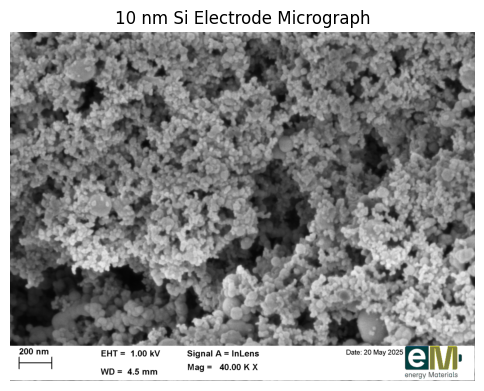

In [6]:
from PIL import Image
import matplotlib.pyplot as plt
# Path to 10 nm Silicon electrode micrograph
img_path = f'{base_path}/Figure 4/Electrodes/Microgrph/10 nm Si-elctrode_Si_rp0001_02.tif'

img = Image.open(img_path)
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title('10 nm Si Electrode Micrograph')
plt.axis('off')
plt.show()